# Choosing Data and Creating Data Set Directory

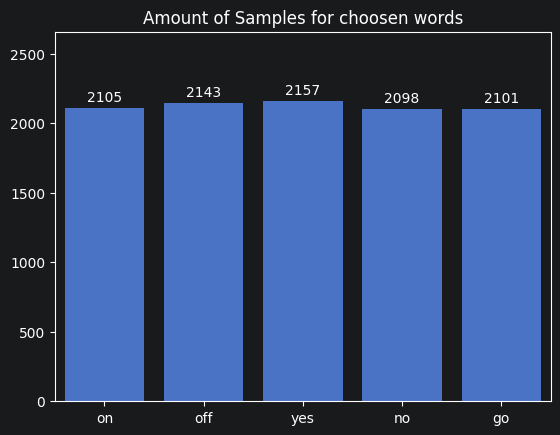

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf

DATASET_PATH = os.path.join('Data', 'Commands')
os.makedirs(DATASET_PATH, exist_ok=True)

CHOSEN_AUDIO = ['on', 'off', 'yes', 'no', 'go']

count = {}
for name in CHOSEN_AUDIO:
    files = os.listdir(os.path.join('Data', name))
    target_samples = []

    for file in files:
        # Loading and Resampling
        sample, sr = librosa.load(os.path.join('Data', name, file))
        sample = librosa.resample(np.asarray(sample,dtype=np.float32), orig_sr=sr,target_sr=8000)

        # Checking Length
        if len(sample) == 8000:

            # Remove DC offset
            sample = sample - np.mean(sample)

            # Normalize audio
            peak = np.max(np.abs(sample))
            if peak > 0:
                sample = sample / peak

            target_samples.append(sample)

            # Saving
            os.makedirs(os.path.join(DATASET_PATH, name), exist_ok=True)
            path = os.path.join(DATASET_PATH, name, file)
            sf.write(path, sample, 8000)

    #Count
    count[name] = len(target_samples)

ax = plt.subplot()
sns.barplot(x=CHOSEN_AUDIO, y=count.values(), ax=ax)
ax.set_ylim(0, max(count.values()) + 500)

# Annotate using bar_label
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

ax.set_title("Amount of Samples for choosen words")


plt.show()

# Dataset
Small (20%) and unsatisfying

In [2]:
import os
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from utils8.data import AudioDataset

# Get Data
path = os.path.join('Data', 'Commands')
classes = ['on', 'off', 'yes', 'no', 'go']
dataset = AudioDataset(path, classes)

# Data Split and Subsets
idx = list(range(len(dataset)))
labels = dataset.labels
train_val_idx, test_idx = train_test_split(idx, test_size=0.8, stratify=labels, random_state=42)

train_val_set = Subset(dataset, train_val_idx)
test_set = Subset(dataset, test_idx)

## Getting Optuna Parameters

In [6]:
import pandas as pd

studies = sorted(os.listdir('optuna_results'))

print('Available studies: ')
for s in studies:
    s = s.replace('(', '_')
    s = s.replace(')', '_')
    parsed_s = s.split('_')
    print(f'{parsed_s[1]}/{parsed_s[2]}/{parsed_s[3]} - {parsed_s[4]}')

last_study_path = os.path.join('optuna_results', studies[-1])
last_study = pd.read_csv(last_study_path)


study = last_study.iloc[0].to_dict()

network_col = ["params_dropout_rate", "params_lr", "params_patience", "params_weight_decay"]
best_params = {}
for col in network_col:
    best_params[col.removeprefix('params_')] = study[col]

best_params

Available studies: 
20/05/2026 - 12:08


{'dropout_rate': 0.0082966517228649,
 'lr': 0.0016068082173041,
 'patience': 5,
 'weight_decay': 0.0001426599145501}

# Network from Scratch

In [8]:
import os
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch import nn,optim
from utils8.dir_managment import clean_dir
from utils8.AudioCNN import AudioCNN
from utils8.training import train_one_fold, get_train_loaders, save_model_dict, save_target_labels


model_name = 'model_commands_scratchlabels'

log_dir = os.path.join('runs', 'training', model_name)
clean_dir(log_dir)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

save_model_dir = os.path.join('Models', model_name)
clean_dir(save_model_dir)
os.makedirs(save_model_dir, exist_ok=True)

model_params = {'dropout_rate': 0.3, 'num_classes': 5}
save_model_dict(model_params, save_model_dir)
save_target_labels(classes, save_model_dir)

N_EPOCHS = 30
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_set)):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')
    # Loaders
    train_loader, val_loader = get_train_loaders(train_val_set, train_idx,val_idx , batch_size=32)

    # Model, Optimizer, Criterion
    criterion = nn.CrossEntropyLoss()
    model =  AudioCNN(dropout_rate=best_params['dropout_rate'], num_classes=5)
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=best_params['patience'])

    # Fold Training
    loss = train_one_fold(fold, model, train_loader, val_loader, optimizer, scheduler, criterion, n_epochs=N_EPOCHS, write_model_dir=save_model_dir, writer=writer)




Cleaning existing files at runs/training/model_commands_scratch...
Cleaning existing files at Models/model_commands_scratch...
Model dict saved in Models/model_commands_scratch/model_dict.json
Labels dict saved in Models/model_commands_scratch/data_labels.json

 ===================== Training Fold 0  ===================== 

Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=1.579504600593022
Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=1.2410611169678825
Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=1.0461971163749695
Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=1.0131390137331826
Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=0.9015882228102002
Saved new best model to Models/model_commands_scratch/fold_0.pth, with new best_val_loss=0.8230121816907611
Saved new best model to Mod

## Evaluation
on Test set

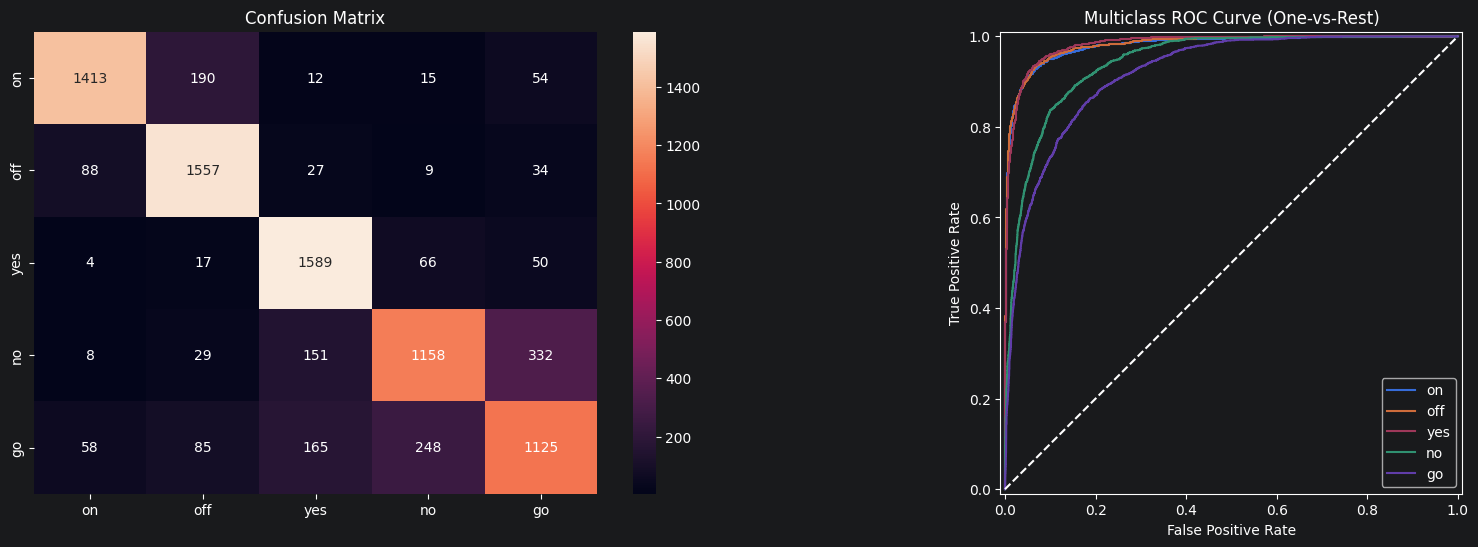

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1684
           1       0.83      0.91      0.87      1715
           2       0.82      0.92      0.87      1726
           3       0.77      0.69      0.73      1678
           4       0.71      0.67      0.69      1681

    accuracy                           0.81      8484
   macro avg       0.81      0.81      0.80      8484
weighted avg       0.81      0.81      0.80      8484



In [13]:
import os
from utils8.Predictor import Predictor

model_path = os.path.join('Models', 'model_commands_scratch')
predictor_obj = Predictor(model_path)

predictor_obj.metric_report(data=test_set)

# Transfer Learning

In [30]:
import os
import json
import torch

path = os.path.join('Models', 'model_2')

with open(os.path.join(path, 'model_dict.json'), 'r', encoding='utf-8-sig') as f:
    model_params = json.load(f)

# Loading Models, Caning FC and Freezing Layers
folds = []
for fold_idx in range(5):

    # Loading Features only
    fold_path = os.path.join(path, f'fold_{fold_idx}.pth')
    model = AudioCNN(dropout_rate=best_params['dropout_rate'], num_classes=5)

    checkpoint = torch.load(fold_path)
    filtered_weights = {k: v for k, v in checkpoint.items() if 'features' in k}
    model.load_state_dict(filtered_weights, strict=False)

    # Frezzing
    for param in model.features.parameters():
        param.requires_grad = False

    folds.append(model)


folds

[AudioCNN(
   (features): Sequential(
     (0): Conv1d(1, 8, kernel_size=(13,), stride=(1,), padding=valid)
     (1): ReLU()
     (2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
     (3): Dropout(p=0.0082966517228649, inplace=False)
     (4): Conv1d(8, 16, kernel_size=(11,), stride=(1,), padding=valid)
     (5): ReLU()
     (6): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
     (7): Dropout(p=0.0082966517228649, inplace=False)
     (8): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=valid)
     (9): ReLU()
     (10): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
     (11): Dropout(p=0.0082966517228649, inplace=False)
     (12): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=valid)
     (13): ReLU()
     (14): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
     (15): Dropout(p=0.0082966517228649, inplace=False)
   )
   (classifier): Sequential(
     (0): F

# Training Loop

In [31]:
import os
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch import nn,optim
from utils8.dir_managment import clean_dir
from utils8.AudioCNN import AudioCNN
from utils8.training import train_one_fold, get_train_loaders, save_model_dict, save_target_labels


model_name = 'model_commands_finetuned'

log_dir = os.path.join('runs', 'training', model_name)
clean_dir(log_dir)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

save_model_dir = os.path.join('Models', model_name)
clean_dir(save_model_dir)
os.makedirs(save_model_dir, exist_ok=True)

model_params = {'dropout_rate': 0.3, 'num_classes': 5}
save_model_dict(model_params, save_model_dir)
save_target_labels(classes, save_model_dir)

N_EPOCHS = 30
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_set)):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')
    # Loaders
    train_loader, val_loader = get_train_loaders(train_val_set, train_idx,val_idx , batch_size=32)

    # Model, Optimizer, Criterion
    criterion = nn.CrossEntropyLoss()
    model =  folds[fold]
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=best_params['patience'])

    # Fold Training
    loss = train_one_fold(fold, model, train_loader, val_loader, optimizer, scheduler, criterion, n_epochs=N_EPOCHS, write_model_dir=save_model_dir, writer=writer)




Model dict saved in Models/model_commands_finetuned/model_dict.json
Labels dict saved in Models/model_commands_finetuned/data_labels.json

 ===================== Training Fold 0  ===================== 

Saved new best model to Models/model_commands_finetuned/fold_0.pth, with new best_val_loss=0.7855355569294521
Saved new best model to Models/model_commands_finetuned/fold_0.pth, with new best_val_loss=0.5722519670213971

 ===================== Training Fold 1  ===================== 

Saved new best model to Models/model_commands_finetuned/fold_1.pth, with new best_val_loss=0.6074571758508682
Saved new best model to Models/model_commands_finetuned/fold_1.pth, with new best_val_loss=0.47763499511139734

 ===================== Training Fold 2  ===================== 

Saved new best model to Models/model_commands_finetuned/fold_2.pth, with new best_val_loss=0.5647350975445339
Saved new best model to Models/model_commands_finetuned/fold_2.pth, with new best_val_loss=0.5362910889089108
Saved 

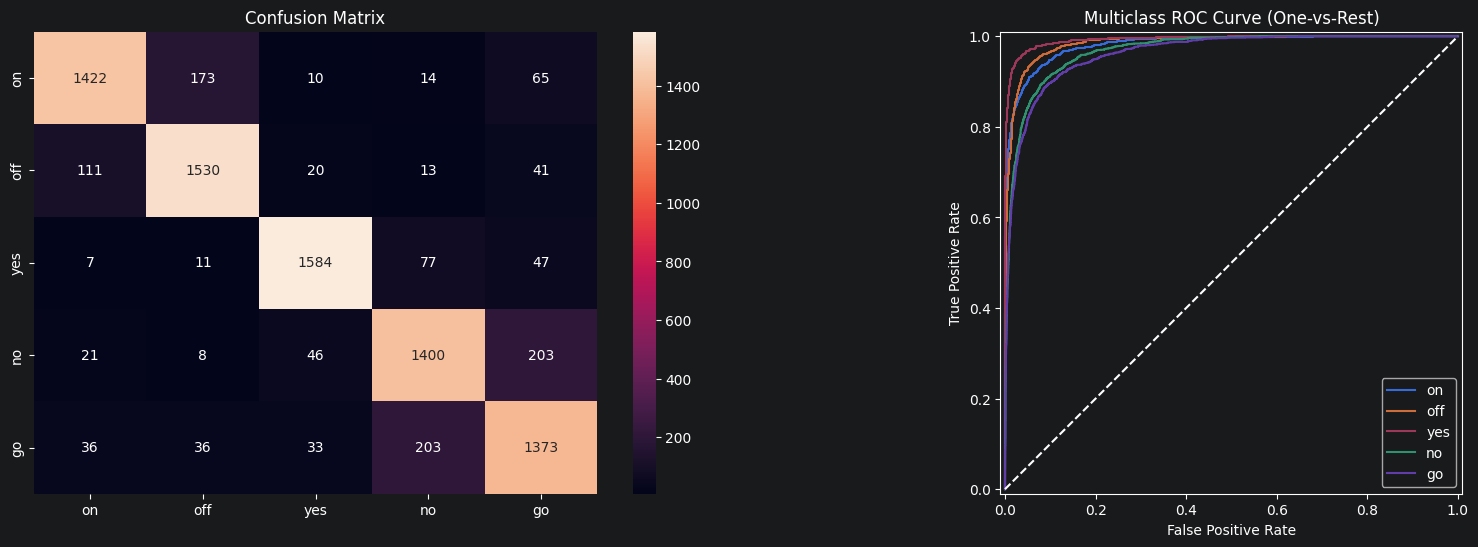

              precision    recall  f1-score   support

           0       0.89      0.84      0.87      1684
           1       0.87      0.89      0.88      1715
           2       0.94      0.92      0.93      1726
           3       0.82      0.83      0.83      1678
           4       0.79      0.82      0.81      1681

    accuracy                           0.86      8484
   macro avg       0.86      0.86      0.86      8484
weighted avg       0.86      0.86      0.86      8484



In [32]:
import os
from utils8.Predictor import Predictor

model_path = os.path.join('Models', 'model_commands_finetuned')
predictor_obj = Predictor(model_path)

predictor_obj.metric_report(data=test_set)

# Statistical Testing

In [3]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from utils8.Predictor import Predictor

model_scratch_path = os.path.join('Models', 'model_commands_scratch')
pred_s = Predictor(model_scratch_path)

model_finetuned_path = os.path.join('Models', 'model_commands_finetuned')
pred_f = Predictor(model_finetuned_path)

# 1. Dummy Data: True labels and predictions from 2 ensemble models
# Let's assume 0 = Incorrect, 1 = Correct prediction for a test set
true_labels = [label for _, label in test_set]


# Simulate predictions
models_preds = pred_s.predict(test_set)
modelf_preds = pred_f.predict(test_set)

# 2. Calculate the outcomes (Correct vs Incorrect)
ms_correct = (models_preds == true_labels)
mf_correct = (modelf_preds == true_labels)

# 3. Build the 2x2 Contingency Table
# True/True, True/False, False/True, False/False
a = np.sum(ms_correct & mf_correct)
b = np.sum(ms_correct & ~mf_correct)
c = np.sum(~ms_correct & mf_correct)
d = np.sum(~ms_correct & ~mf_correct)

table = [[a, b],
         [c, d]]

print("Contingency Table:")
print(f"[{a}, {b}]")
print(f"[{c}, {d}]\n")

# 4. Perform McNemar's Test
# exact=False uses the Chi-Squared distribution (good for large samples)
# correction=True applies Edwards' continuity correction
result = mcnemar(table, exact=False, correction=True)

# 5. Interpret Results
print(f"Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4e}")

alpha = 0.05
if result.pvalue < alpha:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant difference between the two ensemble models.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the two ensemble models.")

Contingency Table:
[6388, 454]
[921, 721]

Statistic: 157.9316
P-value: 3.2032e-36
Conclusion: Reject the null hypothesis. There is a statistically significant difference between the two ensemble models.
